# Funciones de Activación
### Módulo IV · Tema 1.2 — Referencia completa con fórmulas y gráficas

---
## ¿Para qué sirve una función de activación?

Sin función de activación, una red neuronal con 100 capas haría exactamente lo mismo que una sola capa — porque sumar sumas ponderadas sigue siendo una suma ponderada.

La función de activación introduce **no-linealidad**, que es lo que le permite a la red aprender patrones complejos.

```
Entrada X
    ↓
z = Σ(wᵢ · xᵢ) + bias      ← suma ponderada (parte lineal)
    ↓
a = f(z)                     ← función de activación (introduce no-linealidad)
    ↓
Salida hacia la siguiente capa
```

## ¿Cuál función usar dónde?

| Lugar en la red | Función recomendada | Por qué |
|-----------------|--------------------|---------|
| Capas ocultas | **ReLU** | Simple, eficiente, funciona bien en práctica |
| Salida — clasificación binaria | **Sigmoide** | Da probabilidad entre 0 y 1 |
| Salida — clasificación multiclase | **Softmax** | Da probabilidades que suman 1 |
| Salida — regresión | **Ninguna (lineal)** | Necesitamos el número real |
| MPNeuron / Perceptrón | **Escalón** | Solo para estos modelos históricos |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Rango de valores de z para graficar
z = np.linspace(-6, 6, 300)

print("Imports listos")

Imports listos


---
## 1. Función Escalón (Step Function)

**Fórmula:**
```
f(z) = 1  si z ≥ 0
       0  si z <  0
```

**Usada en:** MPNeuron, Perceptrón  
**Problema:** No es diferenciable en z=0 → no se puede usar con gradiente descendente → no sirve para entrenar redes neuronales modernas.

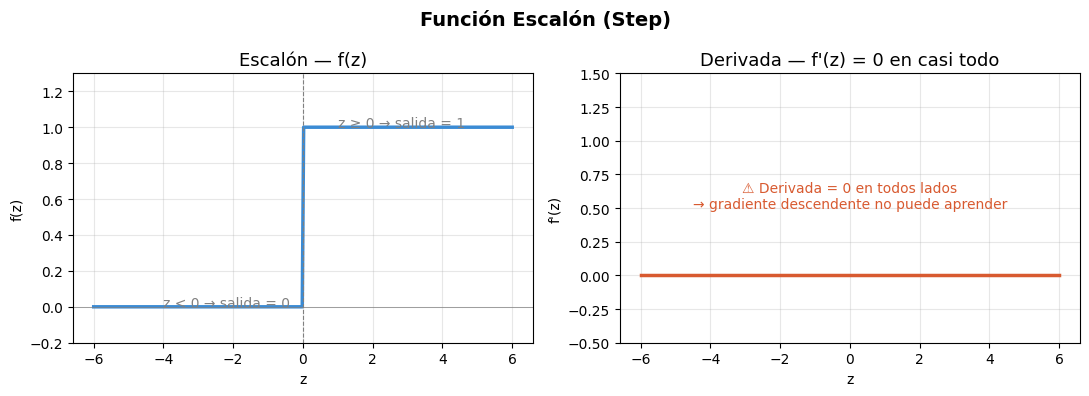

Ejemplos de escalón(z):
  escalon(-3) = 0
  escalon(-1) = 0
  escalon( 0) = 1
  escalon( 1) = 1
  escalon( 3) = 1


In [2]:
# ── Implementación ────────────────────────────────────────────────────
def escalon(z):
    """
    Función escalón (step function).
    Devuelve 1 si z >= 0, 0 si z < 0.
    Es la función más simple — no aprende gradualmente, solo decide.
    """
    return np.where(z >= 0, 1, 0)

# ── Gráfica ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Función
axes[0].plot(z, escalon(z), color='#3B8BD4', linewidth=2.5)
axes[0].axvline(x=0, color='gray', linewidth=0.8, linestyle='--')
axes[0].axhline(y=0, color='gray', linewidth=0.5)
axes[0].set_title('Escalón — f(z)', fontsize=13)
axes[0].set_xlabel('z')
axes[0].set_ylabel('f(z)')
axes[0].set_ylim(-0.2, 1.3)
axes[0].annotate('z < 0 → salida = 0', xy=(-4, 0), fontsize=10, color='gray')
axes[0].annotate('z ≥ 0 → salida = 1', xy=(1,  1), fontsize=10, color='gray')
axes[0].grid(True, alpha=0.3)

# Derivada (prácticamente 0 en todos lados)
deriv = np.zeros_like(z)  # la derivada es 0 en todos lados excepto en z=0
axes[1].plot(z, deriv, color='#D85A30', linewidth=2.5)
axes[1].set_title('Derivada — f\'(z) = 0 en casi todo', fontsize=13)
axes[1].set_xlabel('z')
axes[1].set_ylabel('f\'(z)')
axes[1].set_ylim(-0.5, 1.5)
axes[1].text(0, 0.5, '⚠ Derivada = 0 en todos lados\n→ gradiente descendente no puede aprender',
             ha='center', fontsize=10, color='#D85A30')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Función Escalón (Step)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Ejemplo numérico
print("Ejemplos de escalón(z):")
for val in [-3, -1, 0, 1, 3]:
    print(f"  escalon({val:2d}) = {escalon(np.array([val]))[0]}")

---
## 2. Sigmoide (Sigmoid / Logística)

**Fórmula:**
```
f(z) = 1 / (1 + e^(-z))
```

**Rango:** (0, 1) — nunca llega exactamente a 0 ni a 1  
**Usada en:** Regresión logística, capas de salida para clasificación binaria  
**Problema:** Vanishing gradient — cuando z es muy grande o muy pequeño, la derivada es casi 0, lo que hace que las capas profundas aprendan muy lento.

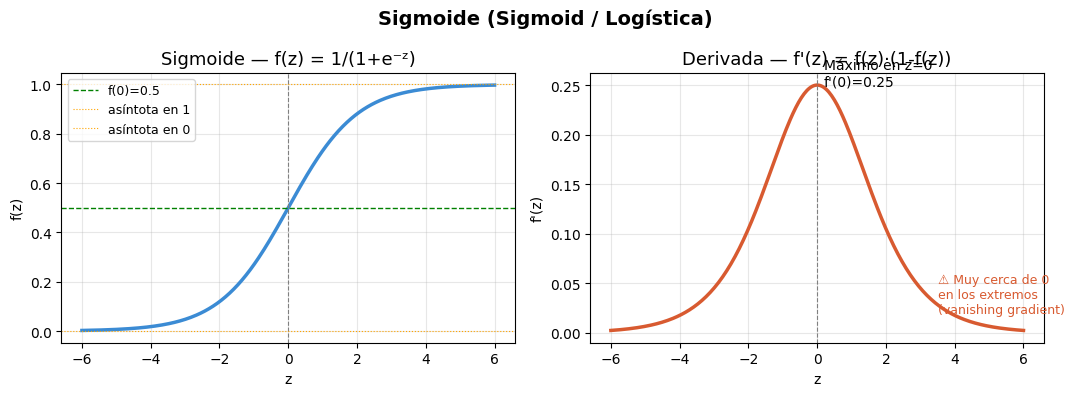

Ejemplos de sigmoide(z):
  sigmoide(-5) = 0.0067  ← clase 0 probable
  sigmoide(-2) = 0.1192  ← clase 0 probable
  sigmoide( 0) = 0.5000  ← clase 0 probable
  sigmoide( 2) = 0.8808  ← clase 1 probable
  sigmoide( 5) = 0.9933  ← clase 1 probable


In [3]:
def sigmoide(z):
    """
    Sigmoide (función logística).
    Rango: (0, 1) — ideal para interpretar como probabilidad.
    f(0) = 0.5 exactamente (punto de indiferencia).
    """
    return 1 / (1 + np.exp(-z))

def sigmoide_derivada(z):
    """
    La derivada de la sigmoide tiene una forma elegante:
    f'(z) = f(z) * (1 - f(z))
    """
    s = sigmoide(z)
    return s * (1 - s)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(z, sigmoide(z), color='#3B8BD4', linewidth=2.5)
axes[0].axhline(y=0.5, color='green', linewidth=1, linestyle='--', label='f(0)=0.5')
axes[0].axvline(x=0,   color='gray',  linewidth=0.8, linestyle='--')
axes[0].axhline(y=1,   color='orange', linewidth=0.8, linestyle=':', label='asíntota en 1')
axes[0].axhline(y=0,   color='orange', linewidth=0.8, linestyle=':', label='asíntota en 0')
axes[0].set_title('Sigmoide — f(z) = 1/(1+e⁻ᶻ)', fontsize=13)
axes[0].set_xlabel('z')
axes[0].set_ylabel('f(z)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(z, sigmoide_derivada(z), color='#D85A30', linewidth=2.5)
axes[1].axvline(x=0, color='gray', linewidth=0.8, linestyle='--')
axes[1].annotate('Máximo en z=0\nf\'(0)=0.25', xy=(0.2, 0.25), fontsize=10)
axes[1].annotate('⚠ Muy cerca de 0\nen los extremos\n(vanishing gradient)', 
                  xy=(3.5, 0.02), fontsize=9, color='#D85A30')
axes[1].set_title('Derivada — f\'(z) = f(z)·(1-f(z))', fontsize=13)
axes[1].set_xlabel('z')
axes[1].set_ylabel('f\'(z)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Sigmoide (Sigmoid / Logística)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Ejemplos de sigmoide(z):")
for val in [-5, -2, 0, 2, 5]:
    s = sigmoide(np.array([val]))[0]
    print(f"  sigmoide({val:2d}) = {s:.4f}  ← {'clase 1 probable' if s > 0.5 else 'clase 0 probable'}")

---
## 3. Tangente Hiperbólica (Tanh)

**Fórmula:**
```
f(z) = (e^z - e^(-z)) / (e^z + e^(-z))
     = 2·sigmoide(2z) - 1
```

**Rango:** (-1, 1) — centrada en 0, a diferencia de la sigmoide  
**Usada en:** Capas ocultas (mejor que sigmoide porque está centrada en 0)  
**Problema:** Sigue teniendo vanishing gradient en los extremos.

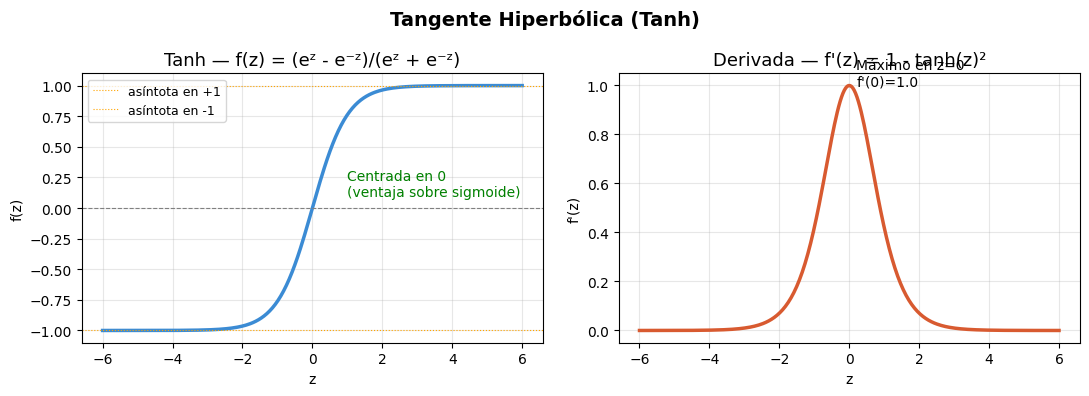

In [4]:
def tanh(z):
    """
    Tangente hiperbólica.
    Rango: (-1, 1). Centrada en 0.
    Mejor que sigmoide para capas ocultas porque los gradientes
    promedio son más cercanos a 0 (menos sesgo).
    numpy ya tiene np.tanh() — esta es solo para mostrar la fórmula.
    """
    return (np.exp(z) - np.exp(-z)) / (np.exp(z) + np.exp(-z))

def tanh_derivada(z):
    """f'(z) = 1 - tanh(z)²"""
    return 1 - tanh(z)**2

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(z, tanh(z), color='#3B8BD4', linewidth=2.5)
axes[0].axhline(y=0,  color='gray',   linewidth=0.8, linestyle='--')
axes[0].axhline(y=1,  color='orange', linewidth=0.8, linestyle=':', label='asíntota en +1')
axes[0].axhline(y=-1, color='orange', linewidth=0.8, linestyle=':', label='asíntota en -1')
axes[0].set_title('Tanh — f(z) = (eᶻ - e⁻ᶻ)/(eᶻ + e⁻ᶻ)', fontsize=13)
axes[0].set_xlabel('z')
axes[0].set_ylabel('f(z)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].annotate('Centrada en 0\n(ventaja sobre sigmoide)', xy=(1, 0.1), fontsize=10, color='green')

axes[1].plot(z, tanh_derivada(z), color='#D85A30', linewidth=2.5)
axes[1].set_title('Derivada — f\'(z) = 1 - tanh(z)²', fontsize=13)
axes[1].set_xlabel('z')
axes[1].set_ylabel('f\'(z)')
axes[1].annotate('Máximo en z=0\nf\'(0)=1.0', xy=(0.2, 1.0), fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Tangente Hiperbólica (Tanh)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. ReLU — Rectified Linear Unit

**Fórmula:**
```
f(z) = max(0, z)
     = z  si z > 0
       0  si z ≤ 0
```

**Rango:** [0, ∞)  
**Usada en:** Capas ocultas de casi todas las redes modernas (CNNs, MLPs)  
**Ventaja:** Computacionalmente barata, resuelve el vanishing gradient  
**Problema:** Dying ReLU — si muchas neuronas reciben z negativo siempre, sus gradientes son 0 y dejan de aprender

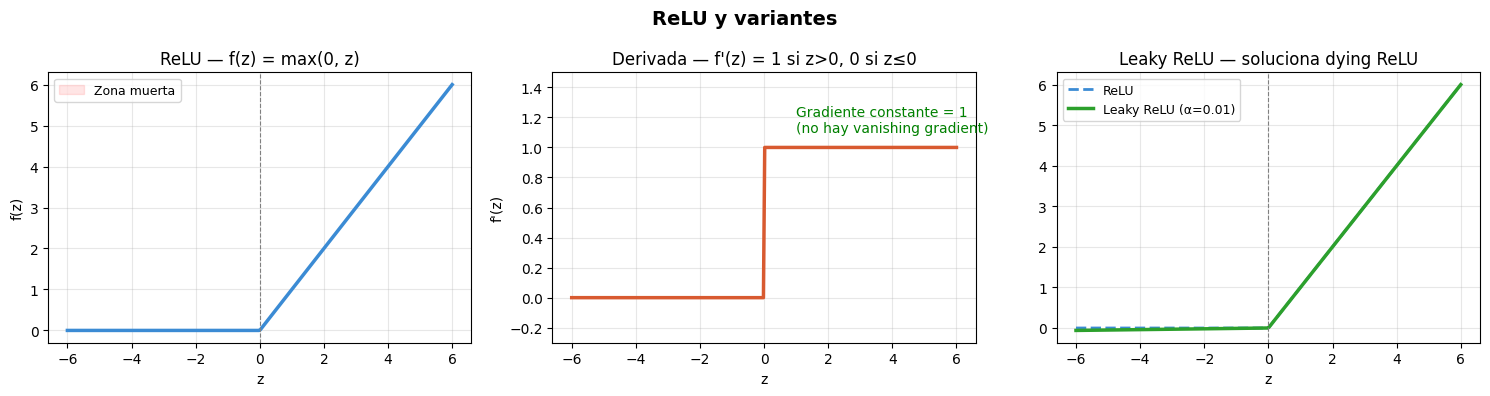

In [5]:
def relu(z):
    """
    ReLU — Rectified Linear Unit.
    La función de activación más usada en redes profundas.
    Muy simple: si z es positivo, lo deja pasar; si es negativo, lo corta a 0.
    """
    return np.maximum(0, z)

def relu_derivada(z):
    """
    La derivada de ReLU es 1 si z>0, 0 si z<=0.
    Muy simple de calcular → entrena rápido.
    """
    return np.where(z > 0, 1, 0)

# Variante: Leaky ReLU — soluciona el dying ReLU
def leaky_relu(z, alpha=0.01):
    """
    Leaky ReLU: en lugar de cortar a 0, usa una pendiente pequeña (alpha)
    para valores negativos. Evita el problema de dying ReLU.
    """
    return np.where(z > 0, z, alpha * z)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ReLU
axes[0].plot(z, relu(z), color='#3B8BD4', linewidth=2.5)
axes[0].axvline(x=0, color='gray', linewidth=0.8, linestyle='--')
axes[0].fill_between(z[z<=0], relu(z)[z<=0], alpha=0.1, color='red', label='Zona muerta')
axes[0].set_title('ReLU — f(z) = max(0, z)', fontsize=12)
axes[0].set_xlabel('z')
axes[0].set_ylabel('f(z)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Derivada de ReLU
axes[1].plot(z, relu_derivada(z), color='#D85A30', linewidth=2.5)
axes[1].set_title('Derivada — f\'(z) = 1 si z>0, 0 si z≤0', fontsize=12)
axes[1].set_xlabel('z')
axes[1].set_ylabel('f\'(z)')
axes[1].set_ylim(-0.3, 1.5)
axes[1].annotate('Gradiente constante = 1\n(no hay vanishing gradient)', 
                  xy=(1, 1.1), fontsize=10, color='green')
axes[1].grid(True, alpha=0.3)

# Leaky ReLU
axes[2].plot(z, relu(z),        color='#3B8BD4', linewidth=2, linestyle='--', label='ReLU')
axes[2].plot(z, leaky_relu(z),  color='#2ca02c', linewidth=2.5, label='Leaky ReLU (α=0.01)')
axes[2].axvline(x=0, color='gray', linewidth=0.8, linestyle='--')
axes[2].set_title('Leaky ReLU — soluciona dying ReLU', fontsize=12)
axes[2].set_xlabel('z')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('ReLU y variantes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Softmax

**Fórmula:**
```
softmax(zᵢ) = e^zᵢ / Σⱼ e^zⱼ
```

**Rango:** (0, 1) para cada clase, y todas suman exactamente 1  
**Usada en:** Capa de salida para clasificación multiclase  
**Diferencia con sigmoide:** La sigmoide calcula cada probabilidad de forma independiente. Softmax las normaliza para que sumen 1 — son comparables entre sí.

In [6]:
def softmax(z):
    """
    Softmax: convierte un vector de números a probabilidades que suman 1.
    Se usa en la capa de salida para clasificación multiclase.
    
    Ejemplo: red para clasificar flores en 3 tipos
    z = [2.0, 1.0, 0.1]   ← suma ponderada de cada clase
    softmax(z) = [0.66, 0.24, 0.10]  ← probabilidades que suman 1
    → predice la clase 0 (la de mayor probabilidad)
    """
    e_z = np.exp(z - np.max(z))   # restar max para estabilidad numérica
    return e_z / e_z.sum()

# Ejemplos
print("Ejemplos de Softmax:")
print()

ejemplos = [
    ([2.0, 1.0, 0.1], ['Setosa', 'Versicolor', 'Virginica']),
    ([5.0, 1.0, 0.1], ['Setosa', 'Versicolor', 'Virginica']),
    ([1.0, 1.0, 1.0], ['Setosa', 'Versicolor', 'Virginica']),
]

for z_ej, clases in ejemplos:
    probs = softmax(np.array(z_ej))
    pred  = clases[np.argmax(probs)]
    print(f"  z = {z_ej}")
    for c, p in zip(clases, probs):
        barra = '█' * int(p * 30)
        marca = ' ← PREDICCIÓN' if c == pred else ''
        print(f"    {c:<12}: {p:.4f}  {barra}{marca}")
    print(f"    Suma: {probs.sum():.4f}  (siempre 1.0)")
    print()

Ejemplos de Softmax:

  z = [2.0, 1.0, 0.1]
    Setosa      : 0.6590  ███████████████████ ← PREDICCIÓN
    Versicolor  : 0.2424  ███████
    Virginica   : 0.0986  ██
    Suma: 1.0000  (siempre 1.0)

  z = [5.0, 1.0, 0.1]
    Setosa      : 0.9749  █████████████████████████████ ← PREDICCIÓN
    Versicolor  : 0.0179  
    Virginica   : 0.0073  
    Suma: 1.0000  (siempre 1.0)

  z = [1.0, 1.0, 1.0]
    Setosa      : 0.3333  ██████████ ← PREDICCIÓN
    Versicolor  : 0.3333  ██████████
    Virginica   : 0.3333  ██████████
    Suma: 1.0000  (siempre 1.0)



---
## 6. Comparación de todas las funciones

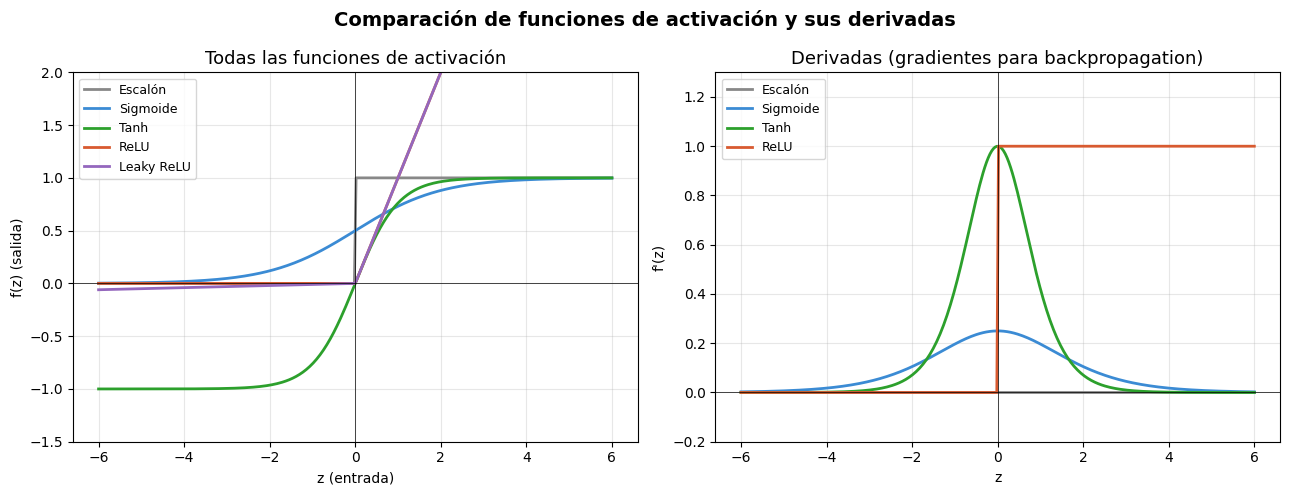

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Funciones
funciones = {
    'Escalón':   (escalon(z),         '#888888'),
    'Sigmoide':  (sigmoide(z),         '#3B8BD4'),
    'Tanh':      (tanh(z),             '#2ca02c'),
    'ReLU':      (relu(z),             '#D85A30'),
    'Leaky ReLU':(leaky_relu(z),       '#9467bd'),
}

for nombre, (vals, color) in funciones.items():
    axes[0].plot(z, vals, label=nombre, color=color, linewidth=2)

axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].axvline(x=0, color='black', linewidth=0.5)
axes[0].set_title('Todas las funciones de activación', fontsize=13)
axes[0].set_xlabel('z (entrada)')
axes[0].set_ylabel('f(z) (salida)')
axes[0].legend(fontsize=9)
axes[0].set_ylim(-1.5, 2)
axes[0].grid(True, alpha=0.3)

# Derivadas
derivadas = {
    'Escalón':   (np.zeros_like(z),    '#888888'),
    'Sigmoide':  (sigmoide_derivada(z),'#3B8BD4'),
    'Tanh':      (tanh_derivada(z),    '#2ca02c'),
    'ReLU':      (relu_derivada(z),    '#D85A30'),
}

for nombre, (vals, color) in derivadas.items():
    axes[1].plot(z, vals, label=nombre, color=color, linewidth=2)

axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].axvline(x=0, color='black', linewidth=0.5)
axes[1].set_title('Derivadas (gradientes para backpropagation)', fontsize=13)
axes[1].set_xlabel('z')
axes[1].set_ylabel('f\'(z)')
axes[1].legend(fontsize=9)
axes[1].set_ylim(-0.2, 1.3)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparación de funciones de activación y sus derivadas',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Uso en Keras — Referencia rápida

```python
from tensorflow import keras

# Forma 1: como string en la capa
keras.layers.Dense(64, activation='relu')
keras.layers.Dense(32, activation='tanh')
keras.layers.Dense(1,  activation='sigmoid')
keras.layers.Dense(10, activation='softmax')

# Forma 2: como capa separada (más control)
keras.layers.Dense(64)
keras.layers.Activation('relu')

# Forma 3: Leaky ReLU (no está como string simple)
keras.layers.Dense(64)
keras.layers.LeakyReLU(alpha=0.01)

# ¿Cuál usar?
# Capas ocultas → 'relu' (default seguro)
# Salida binaria → 'sigmoid'
# Salida multiclase → 'softmax'
# Salida regresión → sin activación (lineal)
```

## 8. Resumen 

| Función | Rango | Derivada máx | Problema | Uso típico |
|---------|-------|--------------|----------|------------|
| Escalón | {0, 1} | 0 | No diferenciable | MPNeuron, Perceptrón |
| Sigmoide | (0, 1) | 0.25 | Vanishing gradient | Salida binaria |
| Tanh | (-1, 1) | 1.0 | Vanishing gradient | Capas ocultas (clásico) |
| ReLU | [0, ∞) | 1 (z>0) | Dying ReLU | Capas ocultas (moderno) |
| Leaky ReLU | (-∞, ∞) | 1 (z>0), α (z<0) | Nada grave | Capas ocultas alternativa |
| Softmax | (0, 1) suma=1 | — | — | Salida multiclase |